# Getting Started with Body Pose

Body Pose enriches the 2D tracking data with **29 key points ("joints") per player**, each
positioned in 3D. This notebook works through loading it, the gating it needs, and one
worked feature — shoulder orientation.

**What you need to know before starting**

| | |
|---|---|
| Frame rate | **25 FPS**, against 10 FPS for tracking, events and phases |
| Coverage | Only detected players get pose — expect gaps |
| Accuracy | Every joint carries `p90_mae_cm`, its own predicted error |
| `z` | Accurate **relative to the player's centroid**, *not* in pitch coordinates |

That last point matters: `z` is not a height above the grass and can be negative. Treat it as
pose geometry, not elevation.

Full matches live on the [Hugging Face Hub](https://huggingface.co/datasets/SkillCorner/opendata-bodypose)
at roughly 600 MB each. This notebook uses the single phase of play committed to the repo, so
nothing needs downloading.

## 1. Load the sample

One 12.3 second Brisbane Roar quick break, second half of match 1925299.

In [1]:
import sys
sys.path.append("../../..")

import matplotlib.pyplot as plt
import pandas as pd

from src.data.pose_loading import (
    JOINTS, SKELETON, iter_sample, joints_to_frame, skeleton_segments,
)
from src.features.pose_orientation import gating_report, shoulder_table

# SkillCorner data-viz palette
GREEN, LIME, AZURE_PALE, AZURE, TEAL = "#00a82f", "#32fe6b", "#7acbff", "#2388c8", "#00838f"
STRUCT, GREY = "#252525", "#E8E8E8"

frames = list(iter_sample())
print(f"{len(frames)} pose frames, {frames[0]['frame']} to {frames[-1]['frame']}")
print(f"{len(JOINTS)} joints per player")

309 pose frames, 124487 to 124795
29 joints per player


## 2. What one record looks like

One JSON object per frame, with `player_data` carrying each player's 2D position and their
`joints` dictionary. A player whose pose could not be resolved has `joints = None` — their
`x`/`y` may still be there.

In [2]:
frame = frames[150]
print(f"frame {frame['frame']}  period {frame['period']}  t={frame['timestamp']}")
print(f"ball: {frame['ball_data']}")

with_pose = [p for p in frame["player_data"] if p["joints"]]
print(f"\nplayers in frame: {len(frame['player_data'])}  with pose: {len(with_pose)}")

player = with_pose[0]
print(f"\nplayer {player['player_id']} at ({player['x']}, {player['y']}):")
for name in ("lShoulder", "rShoulder", "lKnee", "lBigToe"):
    j = player["joints"][name]
    print(f"  {name:<11} xyz={j['xyz']}  p90_mae_cm={j['p90_mae_cm']}")

frame 124637  period 2  t=01:17:40.48
ball: {'x': 34.824, 'y': 29.992, 'z': 0.164, 'is_detected': True}

players in frame: 32  with pose: 17

player 809166 at (34.858, 7.898):
  lShoulder   xyz=[34.729, 7.808, 1.437]  p90_mae_cm=5.36
  rShoulder   xyz=[35.108, 7.878, 1.407]  p90_mae_cm=5.56
  lKnee       xyz=[34.746, 7.997, 0.473]  p90_mae_cm=10.33
  lBigToe     xyz=[34.678, 7.83, 0.012]  p90_mae_cm=26.49


## 3. Flatten to a table

`joints_to_frame` turns the nested records into one row per joint per player per frame, which
is the shape most analysis wants.

In [3]:
joints = joints_to_frame(iter_sample())
print(f"{len(joints):,} joint rows, {joints.player_id.nunique()} players")
joints.head()

143,637 joint rows, 21 players


,frame,period,player_id,joint,x,y,z,p90_mae_cm
0,124487,2,560989,lAnkle,24.264,-8.890,0.338,12.39
1,124487,2,560989,lEar,24.056,-8.397,1.828,6.00
2,124487,2,560989,lElbow,23.889,-8.672,1.334,8.16
3,124487,2,560989,lEye,24.005,-8.283,1.792,6.87
4,124487,2,560989,lHip,24.010,-8.553,0.995,7.27


## 4. Accuracy is not uniform — check before you trust

`p90_mae_cm` is defined so 90% of estimates sit within that radius of the true joint position,
relative to the player's pose. It varies a lot by landmark: torso and head are far more
reliable than fingers and toes.

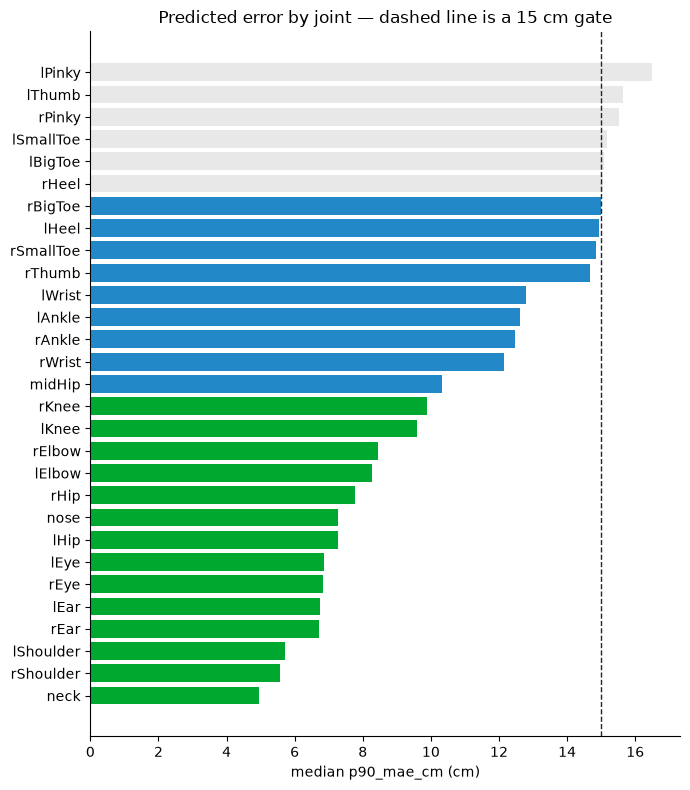

best:  neck at 5.0 cm
worst: lPinky at 16.5 cm


In [4]:
by_joint = joints.groupby("joint")["p90_mae_cm"].median().sort_values()

fig, ax = plt.subplots(figsize=(7, 8))
colors = [GREEN if v <= 10 else (AZURE if v <= 15 else GREY) for v in by_joint.values]
ax.barh(by_joint.index, by_joint.values, color=colors)
ax.axvline(15, color=STRUCT, ls="--", lw=1)
ax.set_xlabel("median p90_mae_cm (cm)")
ax.set_title("Predicted error by joint — dashed line is a 15 cm gate")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"best:  {by_joint.index[0]} at {by_joint.iloc[0]:.1f} cm")
print(f"worst: {by_joint.index[-1]} at {by_joint.iloc[-1]:.1f} cm")

## 5. Draw a skeleton

`SKELETON` lists the joint pairs to connect as bones. Plotting the plan view `(x, y)` and the
front view `(x, z)` side by side shows why `z` is useful for posture even though it is not an
absolute height.

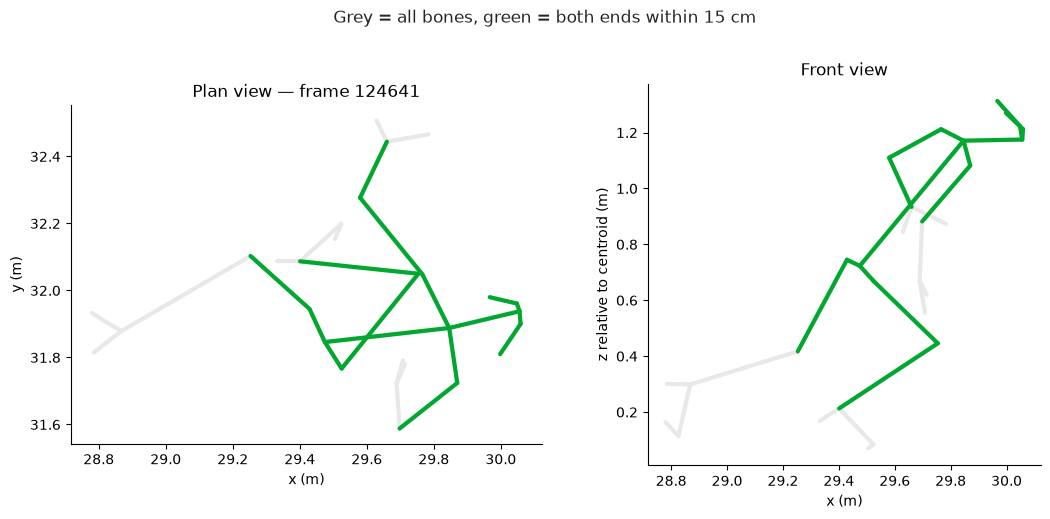

In [5]:
target = joints[joints.player_id == joints.player_id.mode()[0]]
frame_no = int(target.frame.iloc[len(target) // 2])
one = joints[(joints.player_id == target.player_id.iloc[0]) & (joints.frame == frame_no)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for a, b in skeleton_segments(one):
    ax1.plot([a[0], b[0]], [a[1], b[1]], color=GREY, lw=3, solid_capstyle="round")
for a, b in skeleton_segments(one, max_mae_cm=15):
    ax1.plot([a[0], b[0]], [a[1], b[1]], color=GREEN, lw=3, solid_capstyle="round")
ax1.set(xlabel="x (m)", ylabel="y (m)", title=f"Plan view — frame {frame_no}")

for a, b in skeleton_segments(one):
    ax2.plot([a[0], b[0]], [a[2], b[2]], color=GREY, lw=3, solid_capstyle="round")
for a, b in skeleton_segments(one, max_mae_cm=15):
    ax2.plot([a[0], b[0]], [a[2], b[2]], color=GREEN, lw=3, solid_capstyle="round")
ax2.set(xlabel="x (m)", ylabel="z relative to centroid (m)", title="Front view")

for ax in (ax1, ax2):
    ax.set_aspect("equal")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Grey = all bones, green = both ends within 15 cm", y=1.02, color=STRUCT)
fig.tight_layout()
plt.show()

## 6. A worked feature: shoulder orientation

`src/features/pose_orientation.py` computes the ground-plane direction the shoulders face —
the left→right shoulder axis rotated by +90°. 0° points along +x, counter-clockwise positive.

This is a baseline to show how to work with body pose and deduce vectors.

In [6]:
print(gating_report(iter_sample()).to_string(index=False))

                    gate  dropped  remaining
      player-frames seen        0       9888
    no pose (undetected)     4935       4953
      a shoulder missing        0       4953
      shoulders coincide        0       4953
width outside 0.15-0.6 m        5       4948
           error > 15 cm       57       4891


Note the width gate. A collapsed pose still yields an angle — the maths succeeds — but a
0.01 m shoulder width is anatomically impossible and the heading it gives is noise. Checking
only for exactly coincident points would let those through.

In [7]:
shoulders = shoulder_table(iter_sample())
print(f"{len(shoulders):,} rows, {shoulders.is_reliable.sum():,} reliable "
      f"({shoulders.is_reliable.mean():.1%})")

good = shoulders[shoulders.is_reliable]
bad = shoulders[~shoulders.is_reliable]
print(f"reliable shoulder width:   {good.shoulder_width_m.min():.3f}–{good.shoulder_width_m.max():.3f} m")
print(f"rejected shoulder width:   {bad.shoulder_width_m.min():.3f}–{bad.shoulder_width_m.max():.3f} m")
shoulders.head()

4,953 rows, 4,891 reliable (98.7%)
reliable shoulder width:   0.272–0.432 m
rejected shoulder width:   0.014–0.528 m


,frame,frame_10fps,period,t_s,player_id,shoulder_deg,shoulder_width_m,shoulder_err_cm,is_reliable,l_shoulder_x,l_shoulder_y,r_shoulder_x,r_shoulder_y
0,124487,49795,2,4979.48,11897,-152.226656,0.360534,5.76,True,23.020,13.387,22.852,13.706
1,124488,49795,2,4979.52,11897,-150.806591,0.360834,5.66,True,23.041,13.385,22.865,13.700
2,124489,49796,2,4979.56,11897,-151.890584,0.365059,5.78,True,23.055,13.419,22.883,13.741
3,124490,49796,2,4979.60,11897,-150.039427,0.362432,5.67,True,23.073,13.448,22.892,13.762
4,124491,49796,2,4979.64,11897,-149.308819,0.360494,5.68,True,23.075,13.459,22.891,13.769


> **If you differentiate shoulder heading, smooth it first.** At 25 FPS a couple of degrees of
> frame-to-frame jitter becomes tens of degrees per second, so a raw turn rate is
> noise-dominated rather than informative. Also remember the −180/180 wrap: a player crossing
> that boundary will appear to spin most of a full circle in one frame unless you unfold it.

## 7. Joining back to tracking, events and phases

Pose is 25 FPS and everything else in this repo is 10 FPS, so frame numbers are **not**
interchangeable:

```
pose_frame = 2.5 × tracking_frame
```

Every 5th pose frame lands exactly on an even tracking frame. `shoulder_table` already
provides `frame_10fps`, folded with the same rounding the rest of the pipeline uses, so it
joins directly.

In [8]:
phases = pd.read_csv("../../../data/matches/1925299/1925299_phases_of_play.csv")
phase = phases[phases["index"] == 406].iloc[0]

print(f"phase 406: {phase.team_in_possession_shortname} "
      f"{phase.team_in_possession_phase_type}, {phase.duration}s")
print(f"  tracking frames {phase.frame_start}–{phase.frame_end}")
print(f"  pose frames     {phase.frame_start * 2.5:.0f}–{phase.frame_end * 2.5:.0f}")

exact = good[good.frame % 5 == 0]
print(f"\npose frames aligning exactly to tracking: "
      f"{exact.frame.nunique()} of {good.frame.nunique()}")
good[["frame", "frame_10fps", "player_id", "shoulder_deg"]].head()

phase 406: Perth Glory finish, 0.9s
  tracking frames 51760–51769
  pose frames     129400–129422

pose frames aligning exactly to tracking: 62 of 309


,frame,frame_10fps,player_id,shoulder_deg
0,124487,49795,11897,-152.226656
1,124488,49795,11897,-150.806591
2,124489,49796,11897,-151.890584
3,124490,49796,11897,-150.039427
4,124491,49796,11897,-149.308819


## 8. Moving up to a full match

Everything above ran on one phase. Full matches live on the
[Hugging Face Hub](https://huggingface.co/datasets/SkillCorner/opendata-bodypose) — roughly
600 MB zipped each, about 3.3 GB of JSON.

`data/bodypose/MANIFEST.json` records where the files live plus each one's size and SHA256, so
`download_match` can check what it fetched against what was published. The `revision` below is
which version of the dataset to fetch; `main` means whatever is currently published.

In [9]:
from src.data.pose_loading import manifest

meta = manifest()
print(f"dataset  {meta['hf_dataset']}")
print(f"revision {meta['hf_revision']}")
for match_id, info in meta["matches"].items():
    size = meta["files"][info["file"]]["size_bytes"] / 1024**2
    print(f"  {match_id}  {info['fixture']:<30} {info['date']}  {size:>6.0f} MB")

dataset  SkillCorner/opendata-bodypose
revision main
  1925299  Brisbane Roar v Perth Glory    2024-12-21     595 MB
  1996435  Sydney FC v Adelaide United    2025-02-01     614 MB


`download_match` fetches an archive once, checking it against the manifest, and `iter_match`
then streams frames straight out of the zip — no 3.3 GB extraction, constant memory.

The cell below is switched off so this notebook stays quick to run. Set the flag to `True`
to work with the real thing.

In [11]:
from src.data.pose_loading import download_match, iter_match, verify_download

DOWNLOAD_FULL_MATCH = True   # set True to fetch ~600 MB

if DOWNLOAD_FULL_MATCH:
    archive = download_match(1925299, dest_dir=".")
    print(f"downloaded {archive} — checksum ok: {verify_download(archive)}")

    # stream, do not accumulate: a full match is ~45 million joint observations
    frames = pose_frames = 0
    for frame in iter_match(archive):
        frames += 1
        if any(p["joints"] for p in frame["player_data"]):
            pose_frames += 1
    print(f"{frames:,} frames, {pose_frames:,} with pose")
else:
    print("DOWNLOAD_FULL_MATCH is False — skipping the 600 MB download.")
    print("The sample used above covers tracking frames 49795–49918 of match 1925299.")

downloaded 1925299.jsonl.zip — checksum ok: True
153,252 frames, 106,757 with pose


Nothing here is required to use the data. The files are plain HTTP, so this works standalone:

```python
import io, json, zipfile, urllib.request

URL = ("https://huggingface.co/datasets/SkillCorner/opendata-bodypose"
       "/resolve/main/raw/1925299.jsonl.zip")

with urllib.request.urlopen(URL) as response:
    blob = io.BytesIO(response.read())

with zipfile.ZipFile(blob) as zf, zf.open("1925299.jsonl") as fh:
    for line in fh:
        frame = json.loads(line)
```

Or via `huggingface_hub` if you want caching and resume:

```python
from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id="SkillCorner/opendata-bodypose",
    filename="raw/1925299.jsonl.zip",
    repo_type="dataset",
)
```

## 9. Vision map, following US Soccer

The [US Soccer Federation SSAC 2026 repository](https://github.com/USSoccerFederation/ssac26_visual_exploratory_behavior) turns pose into a top-down vision map for one player. Two grids, both on a 1 m pitch, multiplied together:

* **Field of view.** A 120° wedge along the head bearing. A radial Gaussian falls off with distance and an angular Gaussian falls off toward the edge of the wedge. Both decay faster as the player runs faster: their model of a narrower focus at speed.
* **Occlusion.** Every other player casts a shadow away from the observer. How wide that shadow is depends on distance and on shoulder angle: a chest-on torso blocks more than a player turned sideways. The shadow starts behind that player, and each one removes at most 70% of the vision there.

Head bearing is the ground-plane direction from neck to nose. Shoulder bearing is the facing angle from section 6. Speed is the change in `x`/`y` over one frame at 25 fps. Joints worse than 15 cm are dropped, the same gate as the shoulders.

The cell reads the unzipped match and stays inside the Brisbane quick break from section 1. It picks the player-frame, away from the touchline, with the most other players standing in that 120° wedge — the moment where occlusion is actually visible.


phase 397: Brisbane FC quick_break, pose frames 124482–124797
J. Brazete #18  frame 124785  t=01:17:46.40  4.2 m/s  head -62°
13 players in the 120° wedge, 14 casting a shadow
vision covers 20.5% of the pitch; inside the wedge, occlusion blocks 16% of the field of view


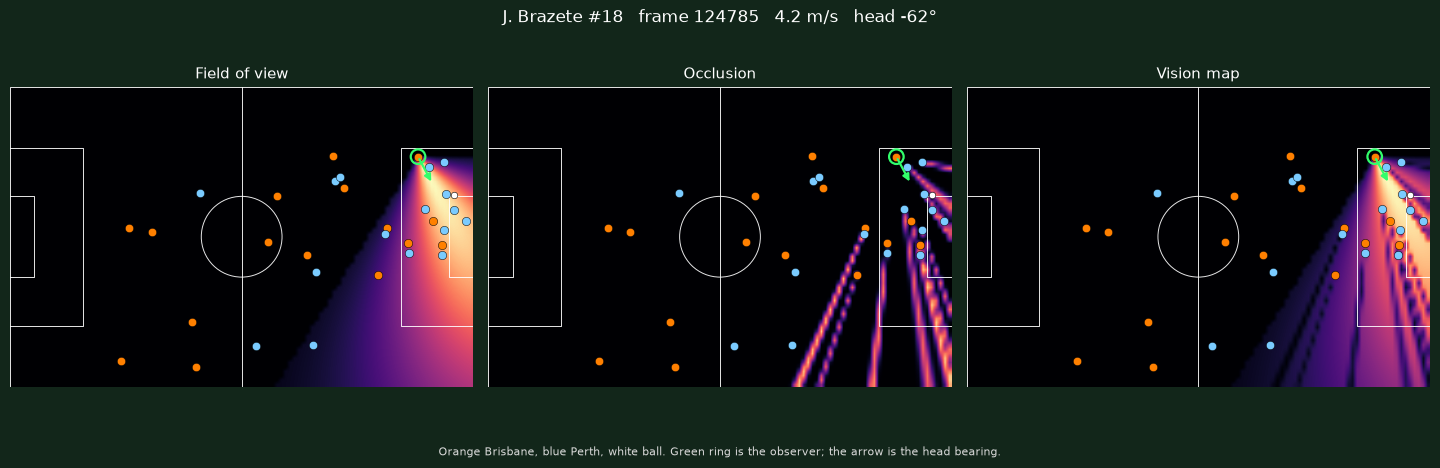

In [12]:
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Circle

sys.path.append("../../..")
from src.features.pose_orientation import PLAUSIBLE_WIDTH_M, shoulder_orientation_deg

# Same accuracy gate as the shoulder feature above.
MAX_ERR_CM = 15.0
PITCH_L, PITCH_W = 105.0, 68.0
# Defaults from US Soccer `Vision`: 120° binocular field, a 1.8 m torso,
# and a shadow that never removes more than 70% of the vision behind a player.
VISION_DEG = 120
HUMAN_WIDTH = 1.8
MAX_OCCLUSION = 0.7

POSE_PATH = Path("1925299.jsonl")
if not POSE_PATH.exists():
    raise FileNotFoundError(
        "Unzip 1925299.jsonl.zip next to this notebook before running this cell."
    )


def joint_xy(player, name):
    joint = (player.get("joints") or {}).get(name)
    if not joint:
        return None
    err = joint.get("p90_mae_cm")
    if err is None or err > MAX_ERR_CM:
        return None
    x, y, _z = joint["xyz"]
    return x, y


def head_angle(player):
    """Ground-plane gaze, neck to nose. None when either joint is missing or noisy."""
    nose, neck = joint_xy(player, "nose"), joint_xy(player, "neck")
    if nose is None or neck is None:
        return None
    dx, dy = nose[0] - neck[0], nose[1] - neck[1]
    if math.hypot(dx, dy) < 0.05:
        return None
    return math.atan2(dy, dx)


def shoulder_angle(player):
    """Facing direction in radians, the same definition as section 6."""
    joints = player.get("joints") or {}
    left, right = joints.get("lShoulder"), joints.get("rShoulder")
    if not left or not right:
        return None
    if max(left.get("p90_mae_cm") or math.inf, right.get("p90_mae_cm") or math.inf) > MAX_ERR_CM:
        return None
    lx, ly, _ = left["xyz"]
    rx, ry, _ = right["xyz"]
    width = math.hypot(rx - lx, ry - ly)
    if not (PLAUSIBLE_WIDTH_M[0] <= width <= PLAUSIBLE_WIDTH_M[1]):
        return None
    deg = shoulder_orientation_deg(lx, ly, rx, ry)
    return None if deg is None else math.radians(deg)


def frame_rows(record, prev_xy):
    rows = []
    for player in record["player_data"]:
        if player.get("x") is None or player.get("y") is None:
            continue
        old = prev_xy.get(player["player_id"])
        speed = 0.0 if old is None else math.hypot(player["x"] - old[0], player["y"] - old[1]) * 25
        rows.append({
            "player_id": player["player_id"],
            "x": player["x"],
            "y": player["y"],
            "head": head_angle(player),
            "shoulder": shoulder_angle(player),
            "speed": speed,
        })
    return rows


def players_in_wedge(observer, rows):
    """Other posed players standing in the 120° wedge, between 3 m and 25 m away."""
    count = 0
    for other in rows:
        if other["player_id"] == observer["player_id"] or other["shoulder"] is None:
            continue
        dx = other["x"] - observer["x"]
        dy = other["y"] - observer["y"]
        dist = math.hypot(dx, dy)
        if not 3.0 <= dist <= 25.0:
            continue
        bearing = math.atan2(dy, dx)
        delta = math.atan2(math.sin(bearing - observer["head"]), math.cos(bearing - observer["head"]))
        if abs(delta) <= math.radians(VISION_DEG / 2):
            count += 1
    return count


def open_at(path, target, n_frames=153_252):
    """Open the jsonl so the next line is the first frame at or after `target`.

    A linear guess overshoots: the opening frames are empty and the later ones
    are much larger. Step back using the average bytes per frame seen so far.
    Returns the handle and the last record strictly before `target`.
    """
    size = path.stat().st_size
    fh = path.open()
    guess = int(size * max(target, 1) / n_frames)
    for _ in range(8):
        fh.seek(max(0, guess))
        if guess:
            fh.readline()
        line = fh.readline()
        if not line:
            guess = max(0, guess - 8_000_000)
            continue
        landed = json.loads(line)
        if landed["frame"] < target:
            return fh, landed
        avg = max(fh.tell(), 1) / max(landed["frame"], 1)
        guess = int(fh.tell() - (landed["frame"] - target + 40) * avg)
    raise RuntimeError(f"could not find frame {target} in {path}")


# Brisbane quick break from section 1, read out of the unzipped match.
phases = pd.read_csv("../../../data/matches/1925299/1925299_phases_of_play.csv")
phase = phases[(phases.frame_start <= 49795) & (phases.frame_end >= 49918)].iloc[0]
pose_start = int(phase.frame_start * 2.5)
pose_end = int(phase.frame_end * 2.5)

fh, record = open_at(POSE_PATH, pose_start)
prev_xy = {
    p["player_id"]: (p["x"], p["y"])
    for p in record["player_data"]
    if p.get("x") is not None and p.get("y") is not None
}
best = None
while record["frame"] < pose_end:
    nxt = json.loads(fh.readline())
    rows = frame_rows(nxt, prev_xy)
    if pose_start <= nxt["frame"] <= pose_end:
        for observer in rows:
            if observer["head"] is None:
                continue
            # On the touchline the wedge points off the pitch and occlusion disappears.
            if abs(observer["y"]) > 25 or abs(observer["x"]) > 40:
                continue
            score = players_in_wedge(observer, rows)
            if best is None or score > best["score"]:
                best = {
                    "score": score,
                    "frame": nxt["frame"],
                    "timestamp": nxt.get("timestamp"),
                    "ball": nxt.get("ball_data"),
                    "rows": rows,
                    "focus_id": observer["player_id"],
                }
    prev_xy = {r["player_id"]: (r["x"], r["y"]) for r in rows}
    record = nxt
fh.close()

focus = next(r for r in best["rows"] if r["player_id"] == best["focus_id"])
others = [
    r for r in best["rows"]
    if r["player_id"] != focus["player_id"] and r["shoulder"] is not None
]

# 1 m cells. Row 0 is the bottom touchline, so imshow(origin="lower") lines up.
xs = np.arange(-PITCH_L / 2 + 0.5, PITCH_L / 2)
ys = np.arange(-PITCH_W / 2 + 0.5, PITCH_W / 2)
XX, YY = np.meshgrid(xs, ys)


def wrap(delta):
    return np.arctan2(np.sin(delta), np.cos(delta))


def field_of_view(x, y, head, speed):
    """Vρ = radial Gaussian × angular Gaussian × the binary 120° wedge."""
    dx, dy = XX - x, YY - y
    dist = np.hypot(dx, dy)
    theta = wrap(np.arctan2(dy, dx) - head)
    wedge = (dist <= 150) & (np.abs(theta) <= np.radians(VISION_DEG / 2))
    # Speed scalers from Vision.field_of_view: linear, then capped.
    cr = min(0.25 * speed + 0.1, 2.6)
    ca = min(0.03 * speed + 0.2, 0.5)
    field = np.exp(-cr * (dist / 75.0) ** 2) * np.exp(-ca * (theta / 0.4) ** 2) * wedge
    peak = field.max()
    return field / peak if peak else field


def apparent_width(x, y, x2, y2, shoulders):
    """Angular width of each torso, seen from (x, y).

    The torso is a rectangle 1.8 m across the shoulders and half that deep,
    rotated by the shoulder facing angle. The width is the larger angle
    between a pair of opposite corners.
    """
    half_w = HUMAN_WIDTH / 2
    half_d = HUMAN_WIDTH / 4
    local = np.array([
        [half_w, half_d], [-half_w, half_d],
        [-half_w, -half_d], [half_w, -half_d],
    ])
    cos_a, sin_a = np.cos(shoulders), np.sin(shoulders)
    rotation = np.stack([
        np.stack([cos_a, -sin_a], axis=1),
        np.stack([sin_a, cos_a], axis=1),
    ], axis=1)
    corners = np.einsum("nij,kj->nki", rotation, local)
    corners += np.stack([x2, y2], axis=1)[:, None, :]
    vec = corners - np.array([x, y])
    near, far = vec[:, [0, 1]], vec[:, [2, 3]]
    dot = np.sum(near * far, axis=2)
    mag = np.linalg.norm(near, axis=2) * np.linalg.norm(far, axis=2)
    return np.arccos(np.clip(dot / (mag + 1e-10), -1.0, 1.0)).max(axis=1)


def occlusion_map(x, y, blockers):
    """Product of every other player's shadow. 1 means nothing is in the way."""
    if not blockers:
        return np.ones_like(XX)
    x2 = np.array([b["x"] for b in blockers])
    y2 = np.array([b["y"] for b in blockers])
    shoulders = np.array([b["shoulder"] for b in blockers])
    dist_ij = np.hypot(x2 - x, y2 - y)
    keep = dist_ij > 0.5
    x2, y2, shoulders, dist_ij = x2[keep], y2[keep], shoulders[keep], dist_ij[keep]
    if len(x2) == 0:
        return np.ones_like(XX)

    direction = np.arctan2(y2 - y, x2 - x)
    theta = wrap(np.arctan2(YY - y, XX - x)[None] - direction[:, None, None])
    omega = apparent_width(x, y, x2, y2, shoulders)
    # Wider, nearer torsos throw a wider ray.
    cq = dist_ij / np.maximum(omega, 1e-6)
    profile = np.exp(-cq[:, None, None] * (theta / 0.2) ** 2)
    profile /= np.maximum(profile.max(axis=(1, 2), keepdims=True), 1e-12)

    half = HUMAN_WIDTH / 2
    left, right = shoulders + np.pi / 2, shoulders - np.pi / 2
    dist_left = np.hypot(x2 + half * np.cos(left) - x, y2 + half * np.sin(left) - y)
    dist_right = np.hypot(x2 + half * np.cos(right) - x, y2 + half * np.sin(right) - y)
    nearest = np.minimum(dist_ij, np.minimum(dist_left, dist_right))
    shadow = np.hypot(XX - x, YY - y)[None] > nearest[:, None, None]
    return np.prod(1.0 - profile * np.where(shadow, MAX_OCCLUSION, 0.0), axis=0)


fov = field_of_view(focus["x"], focus["y"], focus["head"], focus["speed"])
occlusion = occlusion_map(focus["x"], focus["y"], others)
vision = fov * occlusion

meta = json.loads(Path("../../../data/matches/1925299/1925299_match.json").read_text())
roster = {p["id"]: p for p in meta["players"]}
home_id = meta["home_team"]["id"]
who = roster.get(focus["player_id"], {})
name = who.get("short_name", str(focus["player_id"]))
number = who.get("number", "?")
seen = float((vision > 0.05).mean())
inside = fov > 0.05
kept = float(vision[inside].sum() / max(fov[inside].sum(), 1e-9))
print(
    f"phase {int(phase['index'])}: {phase.team_in_possession_shortname} "
    f"{phase.team_in_possession_phase_type}, pose frames {pose_start}–{pose_end}"
)
print(
    f"{name} #{number}  frame {best['frame']}  t={best['timestamp']}  "
    f"{focus['speed']:.1f} m/s  head {math.degrees(focus['head']):.0f}°"
)
print(f"{best['score']} players in the 120° wedge, {len(others)} casting a shadow")
print(
    f"vision covers {seen:.1%} of the pitch; "
    f"inside the wedge, occlusion blocks {1 - kept:.0%} of the field of view"
)

home_c, away_c = "#ff8000", "#7acbff"
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6))
panels = (
    (fov, "Field of view"),
    (1.0 - occlusion, "Occlusion"),
    (vision, "Vision map"),
)


def pitch_lines(ax):
    style = dict(color="white", lw=0.7, alpha=0.9, zorder=3)
    ax.plot([-52.5, 52.5, 52.5, -52.5, -52.5], [-34, -34, 34, 34, -34], **style)
    ax.plot([0, 0], [-34, 34], **style)
    ax.add_patch(Circle((0, 0), 9.15, fill=False, **style))
    for sign in (-1, 1):
        goal_x = sign * 52.5
        for depth, half_w in ((16.5, 20.16), (5.5, 9.16)):
            inner = sign * (52.5 - depth)
            ax.plot([goal_x, inner, inner, goal_x], [-half_w, -half_w, half_w, half_w], **style)


for ax, (grid, title) in zip(axes, panels):
    ax.set_xlim(-PITCH_L / 2, PITCH_L / 2)
    ax.set_ylim(-PITCH_W / 2, PITCH_W / 2)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor("#12261a")
    ax.imshow(
        grid, origin="lower", extent=(-52.5, 52.5, -34, 34),
        cmap="magma", vmin=0, vmax=1, interpolation="bilinear", zorder=1,
    )
    pitch_lines(ax)
    for row in best["rows"]:
        info = roster.get(row["player_id"])
        color = home_c if info and info["team_id"] == home_id else away_c
        ax.scatter(row["x"], row["y"], s=36, c=color, zorder=4, edgecolors="black", linewidths=0.35)
    ax.scatter(
        [focus["x"]], [focus["y"]], s=110, facecolors="none",
        edgecolors="#32fe6b", linewidths=1.6, zorder=6,
    )
    reach = 7.0
    ax.annotate(
        "",
        xy=(
            focus["x"] + reach * math.cos(focus["head"]),
            focus["y"] + reach * math.sin(focus["head"]),
        ),
        xytext=(focus["x"], focus["y"]),
        arrowprops=dict(arrowstyle="-|>", color="#32fe6b", lw=1.6),
        zorder=7,
    )
    ball = best["ball"] or {}
    if ball.get("x") is not None:
        ax.scatter([ball["x"]], [ball["y"]], s=22, c="white", zorder=6, edgecolors="black", linewidths=0.4)
    ax.set_title(title, color="white", fontsize=11)

fig.patch.set_facecolor("#12261a")
fig.suptitle(
    f"{name} #{number}   frame {best['frame']}   "
    f"{focus['speed']:.1f} m/s   head {math.degrees(focus['head']):.0f}°",
    color="white", fontsize=12,
)
fig.text(
    0.5, 0.01,
    "Orange Brisbane, blue Perth, white ball. Green ring is the observer; the arrow is the head bearing.",
    ha="center", color="0.85", fontsize=8,
)
fig.tight_layout(rect=(0, 0.04, 1, 1))


## 10. A scan in each phase

The same vision map works for any player with a head angle. The seven labels below are the phase split from the phases-of-play tutorial, and every one of them occurs in this match.

In possession the clip follows the player on the ball: build-up, create, finish, transition. Out of possession it follows the defender stepping in to win it: low block, medium block, high block. A key moment is a goal or a big chance. A big chance is a shot from inside the penalty area, and when several exist the clip uses the one with the highest possession value at the shot.

Perth's goal runs through a build-up, a create, and a finish, so those three and the matching blocks are that passage. Create, finish, and low block also get a second clip for that chance: the player on the ball, the shot, and the defender stepping in. The medium block in that move has no on-ball challenge, so it stays on the goal. Build-up and high block only occur in the goal. Transition never leads to a shot here, so that clip is the longest spell someone spends on the ball in transition.

Each GIF is about 2.5 seconds, centred on that touch or challenge. The head bearing is averaged over about 0.3 seconds first, so 25 fps jitter in the neck-to-nose angle is not drawn as a scan.

BUILD UP: phase 10 (Perth Glory, 12.1s)  T. Gomulka #12  pose 3060–3121  sweep 449°
CREATE: phase 173 (Perth Glory, 15.5s)  A. Bugarija #16  pose 52061–52122  sweep 340°
FINISH: phase 372 (Brisbane FC, 11.2s)  J. O'Shea #26  pose 115987–116048  sweep 328°
TRANSITION: phase 50 (Perth Glory, 11.1s)  A. Bugarija #16  pose 13715–13776  sweep 431°
LOW BLOCK: phase 39 (Brisbane FC, 14.8s)  A. Faisal #21  pose 11271–11332  sweep 381°
MEDIUM BLOCK: phase 292 (Perth Glory, 11.9s)  Walid Shour #8  pose 85214–85275  sweep 313°
HIGH BLOCK: phase 85 (Perth Glory, 14.6s)  T. Waddingham #16  pose 21778–21839  sweep 351°


**BUILD UP   T. Gomulka #12   head sweep 449°**

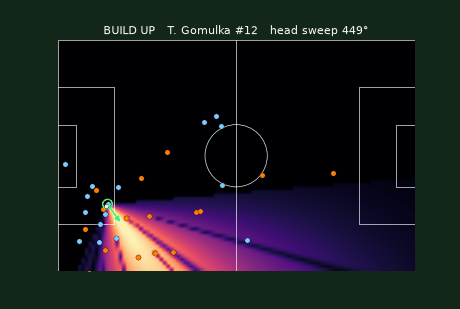

**CREATE   A. Bugarija #16   head sweep 340°**

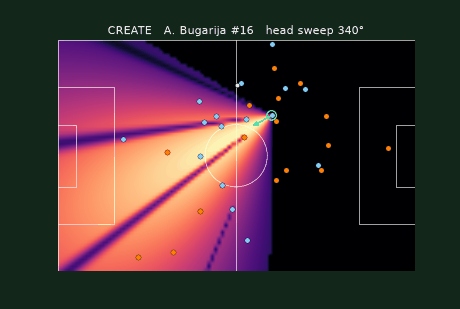

**FINISH   J. O'Shea #26   head sweep 328°**

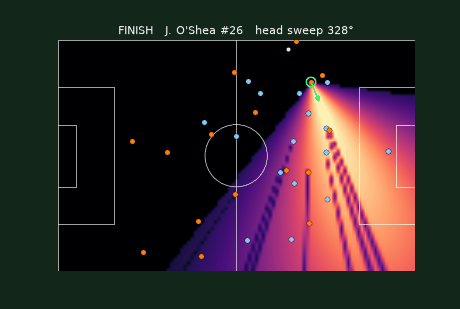

**TRANSITION   A. Bugarija #16   head sweep 431°**

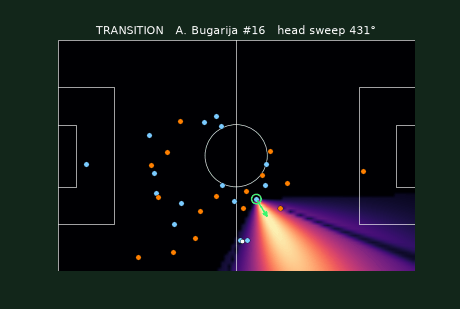

**LOW BLOCK   A. Faisal #21   head sweep 381°**

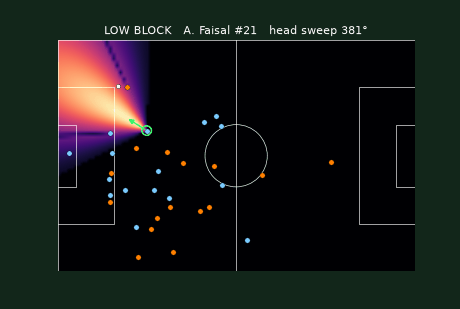

**MEDIUM BLOCK   Walid Shour #8   head sweep 313°**

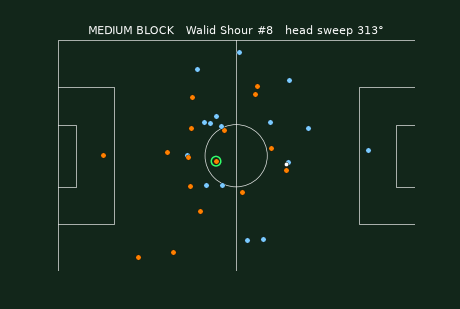

**HIGH BLOCK   T. Waddingham #16   head sweep 351°**

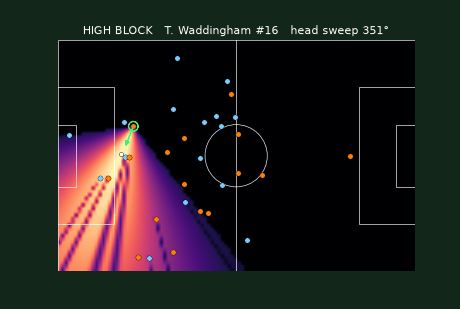

In [13]:
from IPython.display import Image, Markdown, display
from matplotlib.animation import FuncAnimation, PillowWriter

for _name in ("open_at", "frame_rows", "field_of_view", "occlusion_map", "POSE_PATH", "XX", "PITCH_L"):
    if _name not in globals():
        raise RuntimeError("Run the vision-map cell above first.")

POSE_FPS = 25
WINDOW_S = 2.5
WINDOW = int(WINDOW_S * POSE_FPS)   # frames in the clip
SLIDE = int(0.5 * POSE_FPS)         # how far the search window steps
GIF_STRIDE = 3                      # 25 fps pose -> about 8 fps in the gif
GIF_FPS = POSE_FPS / GIF_STRIDE

# In possession: follow the team on the ball. Blocks: follow the other team.
SCENARIOS = [
    ("BUILD UP", "build_up", "in"),
    ("CREATE", "create", "in"),
    ("FINISH", "finish", "in"),
    ("TRANSITION", "transition", "in"),
    ("LOW BLOCK", "low_block", "out"),
    ("MEDIUM BLOCK", "medium_block", "out"),
    ("HIGH BLOCK", "high_block", "out"),
]

meta = json.loads(Path("../../../data/matches/1925299/1925299_match.json").read_text())
roster = {p["id"]: p for p in meta["players"]}
home_id = meta["home_team"]["id"]
away_id = meta["away_team"]["id"]
phases = pd.read_csv("../../../data/matches/1925299/1925299_phases_of_play.csv")
events = pd.read_csv("../../../data/matches/1925299/1925299_dynamic_events.csv")

ENGAGE_RANK = {"recovery_press": 0, "counter_press": 1, "pressing": 2, "pressure": 3}


def defending_team(in_possession_id):
    return away_id if int(in_possession_id) == home_id else home_id


def load_phase(row):
    """Pose frames for one phase. `open_at` seeks, so this does not read the whole match."""
    start = int(row.frame_start * 2.5)
    end = int(row.frame_end * 2.5)
    fh, record = open_at(POSE_PATH, start)
    prev_xy = {
        p["player_id"]: (p["x"], p["y"])
        for p in record["player_data"]
        if p.get("x") is not None and p.get("y") is not None
    }
    frames = []
    while True:
        line = fh.readline()
        if not line:
            break
        nxt = json.loads(line)
        if nxt["frame"] > end:
            break
        if nxt["frame"] >= start:
            frames.append({
                "frame": nxt["frame"],
                "timestamp": nxt.get("timestamp"),
                "ball": nxt.get("ball_data"),
                "rows": frame_rows(nxt, prev_xy),
            })
        prev_xy = {
            p["player_id"]: (p["x"], p["y"])
            for p in nxt["player_data"]
            if p.get("x") is not None and p.get("y") is not None
        }
    fh.close()
    return frames


def circular_smooth(values, win=7):
    """Short average of a head bearing. At 25 fps a raw neck-to-nose angle jitters.

    Seven frames is about 0.3 s. Sin and cos are averaged separately so the
    bearing does not break when it crosses ±180°.
    """
    half = win // 2
    smoothed = []
    for i in range(len(values)):
        chunk = [v for v in values[max(0, i - half):i + half + 1] if v is not None]
        if len(chunk) < 3:
            smoothed.append(values[i])
        else:
            smoothed.append(math.atan2(
                sum(math.sin(v) for v in chunk),
                sum(math.cos(v) for v in chunk),
            ))
    return smoothed


def head_series(frames, player_id):
    values = []
    for fr in frames:
        row = next((r for r in fr["rows"] if r["player_id"] == player_id), None)
        values.append(None if row is None else row["head"])
    return values


def head_sweep(angles):
    present = [a for a in angles if a is not None]
    total = 0.0
    for a, b in zip(present, present[1:]):
        total += abs(math.atan2(math.sin(b - a), math.cos(b - a)))
    return total


def clip_around(frames, mid_pose):
    """2.5 s of pose centred on one event, clipped to the frames that were loaded."""
    if not frames:
        return []
    idx = min(range(len(frames)), key=lambda i: abs(frames[i]["frame"] - mid_pose))
    length = min(WINDOW, len(frames))
    start = max(0, min(idx - length // 2, len(frames) - length))
    return frames[start:start + length]


def possession_chain(shot_phase_index):
    """Phases of one team possession, walking back from the shot while it still leads to a shot or a goal."""
    prev = phases[phases["index"] <= shot_phase_index].sort_values("index", ascending=False)
    team = None
    chain = []
    for _, phase in prev.iterrows():
        if team is None:
            team = phase.team_in_possession_id
        if phase.team_in_possession_id != team:
            break
        if not (bool(phase.team_possession_lead_to_shot) or bool(phase.team_possession_lead_to_goal)):
            break
        chain.append(phase)
    return list(reversed(chain))


def on_ball_event(row, kind):
    """The shot if this phase contains one, otherwise the longest touch that leads into it."""
    poss = events[
        (events.event_type == "player_possession")
        & (events.phase_index == row["index"])
    ]
    if len(poss) == 0:
        return None
    shots = poss[poss.end_type == "shot"]
    word = "goal" if kind == "goal" else "big chance"
    if len(shots):
        ev = shots.sort_values("frame_start").iloc[-1]
        return ev, f"shot, {word}"
    flag = "lead_to_goal" if kind == "goal" else "lead_to_shot"
    led = poss[poss[flag] == True]
    ev = (led if len(led) else poss).sort_values("duration").iloc[-1]
    return ev, f"on the ball, {word}"


def intercept_event(row, kind):
    """The defender stepping into the touch: recovery press, then press, then pressure."""
    eng = events[
        (events.event_type == "on_ball_engagement")
        & (events.phase_index == row["index"])
    ].copy()
    if len(eng) == 0:
        return None
    eng["_rank"] = eng.event_subtype.map(lambda s: ENGAGE_RANK.get(s, 9))
    ev = eng.sort_values(["_rank", "frame_end"], ascending=[True, False]).iloc[0]
    word = "goal" if kind == "goal" else "big chance"
    name = str(ev.event_subtype).replace("_", " ")
    return ev, f"intercepting ({name}), {word}"


def focus_moments(phase_type, side):
    """Goal first, then the best other penalty-area shot that uses this phase type.

    A big chance is a shot from inside the box, ranked by possession value at
    the shot. Attacking clips follow the player on the ball. Defending clips
    follow the defender stepping into that touch. If neither a goal nor a big
    chance uses this phase type, the longest on-ball spell is used.
    """
    column = (
        "team_in_possession_phase_type" if side == "in"
        else "team_out_of_possession_phase_type"
    )
    moments = []
    used = set()

    goal_pool = phases[
        (phases[column] == phase_type) & (phases.team_possession_lead_to_goal == True)
    ]
    if len(goal_pool):
        row = goal_pool.iloc[0]
        picked = on_ball_event(row, "goal") if side == "in" else intercept_event(row, "goal")
        if picked is not None:
            ev, role = picked
            moments.append((row, int(ev.player_id), ev, role, ""))
            used.add(int(row["index"]))

    shots = events[
        (events.event_type == "player_possession")
        & (events.end_type == "shot")
        & (events.penalty_area_end == True)
        & (events.lead_to_goal != True)
    ]
    best_row = None
    best_score = -1.0
    for _, shot in shots.iterrows():
        epv = shot.possession_epv_for_end
        score = float(epv) if pd.notna(epv) else 0.0
        if score <= best_score:
            continue
        for phase in possession_chain(int(shot.phase_index)):
            if phase[column] == phase_type and int(phase["index"]) not in used:
                best_score = score
                best_row = phase
                break
    if best_row is not None:
        picked = (
            on_ball_event(best_row, "chance") if side == "in"
            else intercept_event(best_row, "chance")
        )
        if picked is not None:
            ev, role = picked
            moments.append((best_row, int(ev.player_id), ev, role, "_chance"))

    if moments:
        return moments

    if side == "in":
        poss = events[
            (events.event_type == "player_possession")
            & (events.team_in_possession_phase_type == phase_type)
        ]
        ev = poss.sort_values("duration").iloc[-1]
        row = phases[phases["index"] == ev.phase_index].iloc[0]
        return [(row, int(ev.player_id), ev, "on the ball", "")]

    eng = events[
        (events.event_type == "on_ball_engagement")
        & (events.team_out_of_possession_phase_type == phase_type)
        & (events.event_subtype.isin(ENGAGE_RANK))
    ].copy()
    eng["_rank"] = eng.event_subtype.map(ENGAGE_RANK)
    ev = eng.sort_values(["_rank", "duration"], ascending=[True, False]).iloc[0]
    row = phases[phases["index"] == ev.phase_index].iloc[0]
    name = str(ev.event_subtype).replace("_", " ")
    return [(row, int(ev.player_id), ev, f"intercepting ({name})", "")]


def draw_pitch(ax):
    style = dict(color="white", lw=0.7, alpha=0.9, zorder=3)
    ax.plot([-52.5, 52.5, 52.5, -52.5, -52.5], [-34, -34, 34, 34, -34], **style)
    ax.plot([0, 0], [-34, 34], **style)
    ax.add_patch(Circle((0, 0), 9.15, fill=False, **style))
    for sign in (-1, 1):
        goal_x = sign * 52.5
        for depth, half_w in ((16.5, 20.16), (5.5, 9.16)):
            inner = sign * (52.5 - depth)
            ax.plot([goal_x, inner, inner, goal_x], [-half_w, -half_w, half_w, half_w], **style)


def write_gif(clip, focus_id, heads, title, path):
    """One vision-map frame every third pose frame, played at about 8 fps."""
    sampled = list(zip(clip[::GIF_STRIDE], heads[::GIF_STRIDE]))
    fig, ax = plt.subplots(figsize=(6.4, 4.3))
    fig.patch.set_facecolor("#12261a")

    def draw(i):
        fr, held_head = sampled[i]
        rows = fr["rows"]
        focus = next((r for r in rows if r["player_id"] == focus_id), None)
        ax.clear()
        ax.set_xlim(-PITCH_L / 2, PITCH_L / 2)
        ax.set_ylim(-PITCH_W / 2, PITCH_W / 2)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_facecolor("#12261a")
        if focus is not None and held_head is not None:
            others = [
                r for r in rows
                if r["player_id"] != focus_id and r["shoulder"] is not None
            ]
            vision = field_of_view(focus["x"], focus["y"], held_head, focus["speed"])
            vision = vision * occlusion_map(focus["x"], focus["y"], others)
            ax.imshow(
                vision, origin="lower", extent=(-52.5, 52.5, -34, 34),
                cmap="magma", vmin=0, vmax=1, interpolation="bilinear", zorder=1,
            )
        draw_pitch(ax)
        for row in rows:
            info = roster.get(row["player_id"])
            color = home_c if info and info["team_id"] == home_id else away_c
            ax.scatter(
                row["x"], row["y"], s=28, c=color, zorder=4,
                edgecolors="black", linewidths=0.3,
            )
        if focus is not None:
            ax.scatter(
                [focus["x"]], [focus["y"]], s=90, facecolors="none",
                edgecolors="#32fe6b", linewidths=1.5, zorder=6,
            )
            if held_head is not None:
                reach = 7.0
                ax.annotate(
                    "",
                    xy=(
                        focus["x"] + reach * math.cos(held_head),
                        focus["y"] + reach * math.sin(held_head),
                    ),
                    xytext=(focus["x"], focus["y"]),
                    arrowprops=dict(arrowstyle="-|>", color="#32fe6b", lw=1.5),
                    zorder=7,
                )
        ball = fr["ball"] or {}
        if ball.get("x") is not None:
            ax.scatter(
                [ball["x"]], [ball["y"]], s=18, c="white", zorder=6,
                edgecolors="black", linewidths=0.4,
            )
        ax.set_title(title, color="white", fontsize=11)

    anim = FuncAnimation(fig, draw, frames=len(sampled), interval=int(1000 / GIF_FPS))
    anim.save(
        path, writer=PillowWriter(fps=GIF_FPS), dpi=72,
        savefig_kwargs={"facecolor": fig.get_facecolor()},
    )
    plt.close(fig)


home_c, away_c = "#ff8000", "#7acbff"
clips = []

for label, phase_type, side in SCENARIOS:
    for row, player_id, ev, role, suffix in focus_moments(phase_type, side):
        frames = load_phase(row)
        mid = (ev.frame_start + ev.frame_end) / 2 * 2.5
        clip = clip_around(frames, mid)
        if not clip:
            print(f"{label}: no pose frames in phase {int(row['index'])}")
            continue
        who = roster.get(player_id, {})
        name = who.get("short_name", str(player_id))
        number = who.get("number", "?")
        heads = circular_smooth(head_series(clip, player_id))
        covered = sum(h is not None for h in heads) / len(heads)
        path = Path(f"vision_{phase_type}{suffix}.gif")
        title = f"{label}   {name} #{number}   {role}"
        print(
            f"{label}: phase {int(row['index'])} ({row.team_in_possession_shortname}, "
            f"{row.duration:.1f}s)  {name} #{number}  {role}  "
            f"pose {clip[0]['frame']}-{clip[-1]['frame']}  head on {covered:.0%} of frames"
        )
        write_gif(clip, player_id, heads, title, path)
        clips.append((label, path, title))

for label, path, title in clips:
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(path)))